# Phase 2.5 Scenario Memory Evaluation

Thin notebook for running the scenario-sliced temporal-memory evaluator and inspecting artifacts. Metrics are future-pseudo projected-depth occupancy metrics, not dense simulator 3D ground-truth IoU.


## 1. Setup


In [1]:
from __future__ import annotations

import json
from pathlib import Path

import pandas as pd
from IPython.display import Image, Markdown, display

from src.evaluation.phase2_carla_eval import (
    ScenarioMemoryEvalConfig,
    run_scenario_memory_evaluation,
)

OUTPUT_DIR = Path("outputs/phase2/scenario_memory")
MAX_SCAN_FRAMES = 2000
ANCHORS_PER_SLICE = 50
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


## 2. Run Scenario Memory Evaluation


In [2]:
config = ScenarioMemoryEvalConfig(
    max_scan_frames=MAX_SCAN_FRAMES,
    anchors_per_slice=ANCHORS_PER_SLICE,
    output_dir=OUTPUT_DIR,
    bev_frame_count_per_slice=2,
)

artifacts = run_scenario_memory_evaluation(config=config)
for name, path in artifacts.__dict__.items():
    print(f"{name}: {path}")


d:\carla\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
'The read operation timed out' thrown while requesting GET https://huggingface.co/datasets/immanuelpeter/carla-autopilot-multimodal-dataset/resolve/e3ec78df1c561370c25364fa1b1daed03af754aa/data/validation-00004-of-00072.parquet
Retrying in 1s [Retry 1/5].
'The read operation timed out' thrown while requesting GET https://huggingface.co/datasets/immanuelpeter/carla-autopilot-multimodal-dataset/resolve/e3ec78df1c561370c25364fa1b1daed03af754aa/data/validation-00004-of-00072.parquet
Retrying in 2s [Retry 2/5].


eval_summary: outputs\phase2\scenario_memory\scenario_memory_eval_summary.json
by_slice_iou: outputs\phase2\scenario_memory\scenario_memory_by_slice_iou.json
selected_anchors: outputs\phase2\scenario_memory\scenario_memory_selected_anchors.jsonl
bev_images: (WindowsPath('outputs/phase2/scenario_memory/scenario_memory_bev/vehicle_change/vehicle_change_00046_230.png'), WindowsPath('outputs/phase2/scenario_memory/scenario_memory_bev/vehicle_change/vehicle_change_00047_235.png'), WindowsPath('outputs/phase2/scenario_memory/scenario_memory_bev/sparse_depth/sparse_depth_00004_20.png'), WindowsPath('outputs/phase2/scenario_memory/scenario_memory_bev/sparse_depth/sparse_depth_00005_25.png'), WindowsPath('outputs/phase2/scenario_memory/scenario_memory_bev/dense_traffic/dense_traffic_00004_20.png'), WindowsPath('outputs/phase2/scenario_memory/scenario_memory_bev/dense_traffic/dense_traffic_00005_25.png'), WindowsPath('outputs/phase2/scenario_memory/scenario_memory_bev/high_disagreement/high_disa

## 3. Selected Anchor Counts


In [3]:
summary = json.loads(artifacts.eval_summary.read_text(encoding="utf-8"))
counts = pd.DataFrame(
    [
        {"slice": slice_name, "selected_anchor_count": count}
        for slice_name, count in summary["selected_anchor_counts"].items()
    ]
)
display(counts)
print(json.dumps(summary["selection_thresholds"], indent=2))


,slice,selected_anchor_count
0,vehicle_change,50
1,sparse_depth,50
2,turning,0
3,dense_traffic,50
4,high_disagreement,50


{
  "min_vehicle_union": 1,
  "sparse_depth_quantile": 0.25,
  "sparse_depth_threshold": 0.0018395833333333333,
  "turn_steer_threshold": 0.15,
  "turn_yaw_delta_threshold_degrees": 5.0,
  "dense_traffic_min_nearby": 10
}


## 4. Per-Slice IoU


In [4]:
by_slice = json.loads(artifacts.by_slice_iou.read_text(encoding="utf-8"))
rows = []
for slice_name, payload in by_slice["slices"].items():
    for row in payload["classes"]:
        rows.append(
            {
                "slice": slice_name,
                "class_name": row["class_name"],
                "baseline_iou": row["baseline_iou"],
                "temporal_iou": row["temporal_iou"],
                "delta": row["delta"],
                "baseline_union": row["baseline_union"],
                "temporal_union": row["temporal_union"],
                "informative": row["informative"],
            }
        )

df = pd.DataFrame(rows)
display(
    df.style.format(
        {
            "baseline_iou": "{:.3f}",
            "temporal_iou": "{:.3f}",
            "delta": "{:+.3f}",
        }
    )
)


,slice,class_name,baseline_iou,temporal_iou,delta,baseline_union,temporal_union,informative
0,vehicle_change,pedestrian,1.000,1.000,+0.000,0,0,False
1,vehicle_change,road,0.210,0.210,-0.000,33778,33786,True
2,vehicle_change,vehicle,0.216,0.217,+0.001,8805,8808,True
3,sparse_depth,pedestrian,1.000,1.000,+0.000,0,0,False
4,sparse_depth,road,0.199,0.199,-0.000,27913,27927,True
5,sparse_depth,vehicle,0.282,0.292,+0.010,2131,2131,True
6,dense_traffic,pedestrian,1.000,1.000,+0.000,0,0,False
7,dense_traffic,road,0.202,0.202,-0.000,40093,40094,True
8,dense_traffic,vehicle,0.088,0.088,+0.000,228,228,True
9,high_disagreement,pedestrian,1.000,1.000,+0.000,0,0,False


## 5. Selected Anchors


In [5]:
selected_records = [
    json.loads(line)
    for line in artifacts.selected_anchors.read_text(encoding="utf-8").splitlines()
    if line.strip()
]
selected_df = pd.DataFrame(selected_records)
display(selected_df.head(20))


,slice,anchor_index,run_id,frame,all_slice_labels,depth_coverage,abs_steer,yaw_delta_degrees,nearby_vehicles_50m,total_npc_vehicles,disagreement_rate,vehicle_union,new_vehicle_voxel_count
0,vehicle_change,46,run_008,230,"[vehicle_change, dense_traffic]",0.002129,0.0,0.0,3,40,0.0,4,4
1,vehicle_change,47,run_008,235,"[vehicle_change, dense_traffic]",0.002042,0.0,0.0,3,40,0.0,7,7
2,vehicle_change,48,run_008,240,"[vehicle_change, dense_traffic]",0.002102,0.0,0.0,3,40,0.0,13,13
3,vehicle_change,49,run_008,245,"[vehicle_change, dense_traffic]",0.002042,0.0,0.0,3,40,0.0,20,20
4,vehicle_change,50,run_008,250,"[vehicle_change, dense_traffic]",0.002058,0.0,0.0,3,40,0.0,28,24
5,vehicle_change,51,run_008,255,"[vehicle_change, dense_traffic]",0.002098,0.0,0.0,2,40,0.0,37,34
6,vehicle_change,52,run_008,260,"[vehicle_change, dense_traffic]",0.002023,0.0,0.0,2,40,0.0,52,46
7,vehicle_change,53,run_008,265,"[vehicle_change, sparse_depth, dense_traffic]",0.001829,0.0,0.0,2,40,0.0,67,60
8,vehicle_change,54,run_008,270,"[vehicle_change, dense_traffic]",0.001863,0.0,0.0,2,40,0.0,93,85
9,vehicle_change,55,run_008,275,"[vehicle_change, dense_traffic]",0.001908,0.0,0.0,2,40,0.0,136,123


## 6. BEV Visual Checks


**vehicle_change / vehicle_change_00046_230.png**

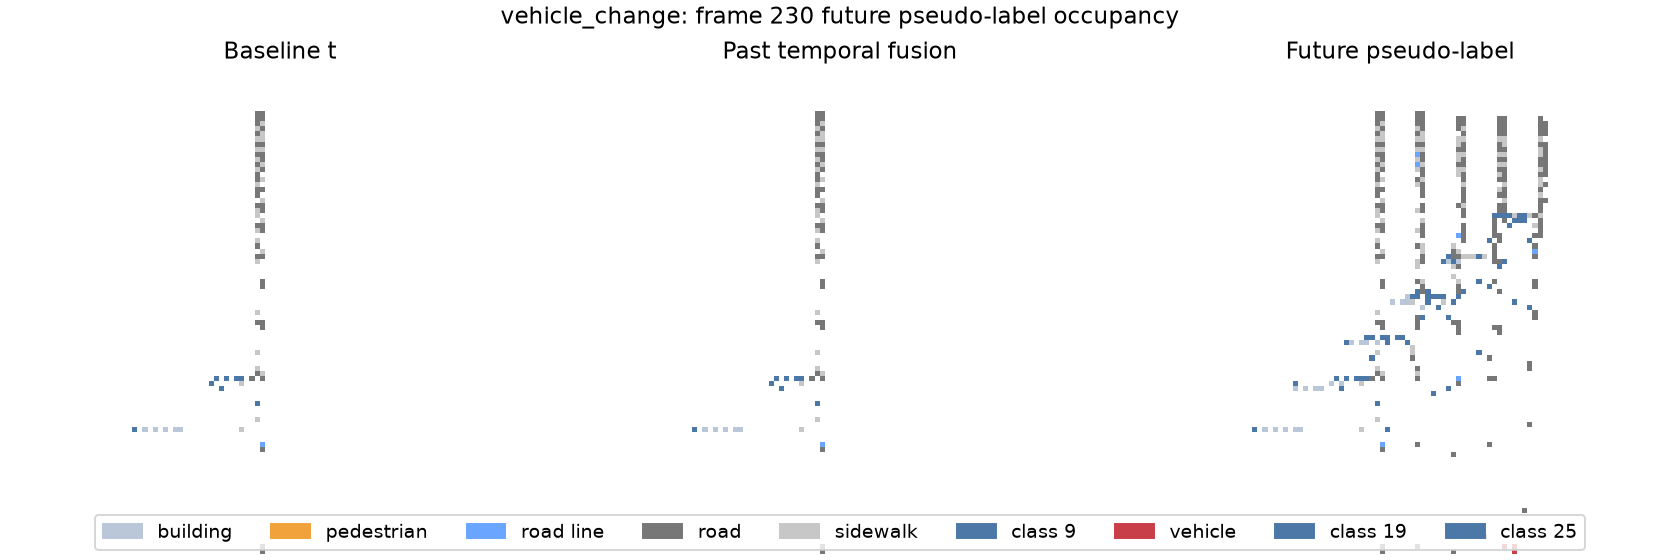

**vehicle_change / vehicle_change_00047_235.png**

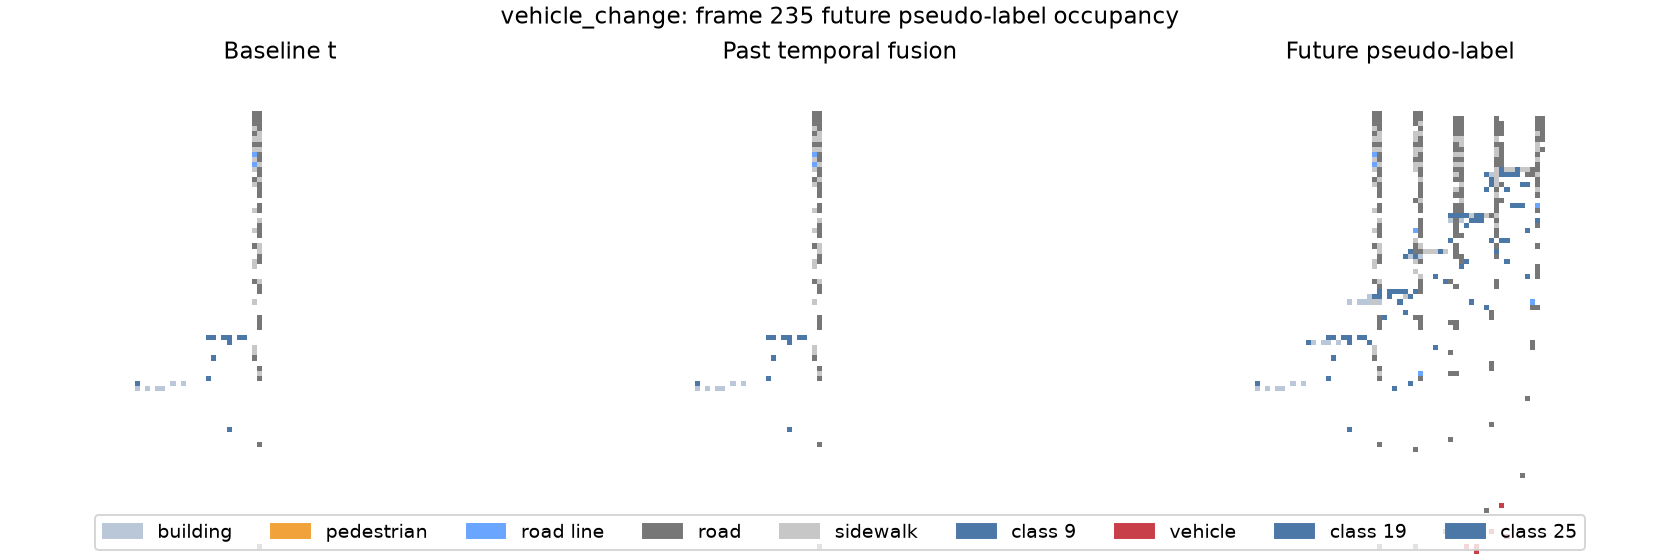

**sparse_depth / sparse_depth_00004_20.png**

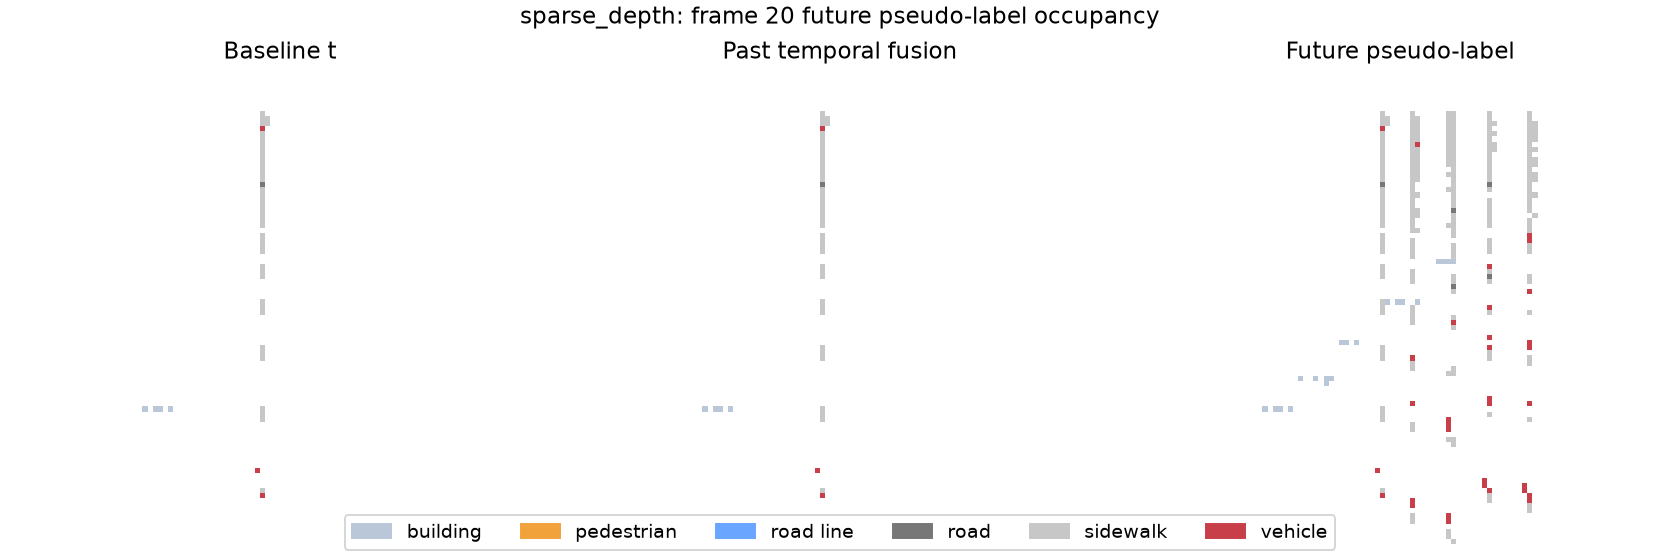

**sparse_depth / sparse_depth_00005_25.png**

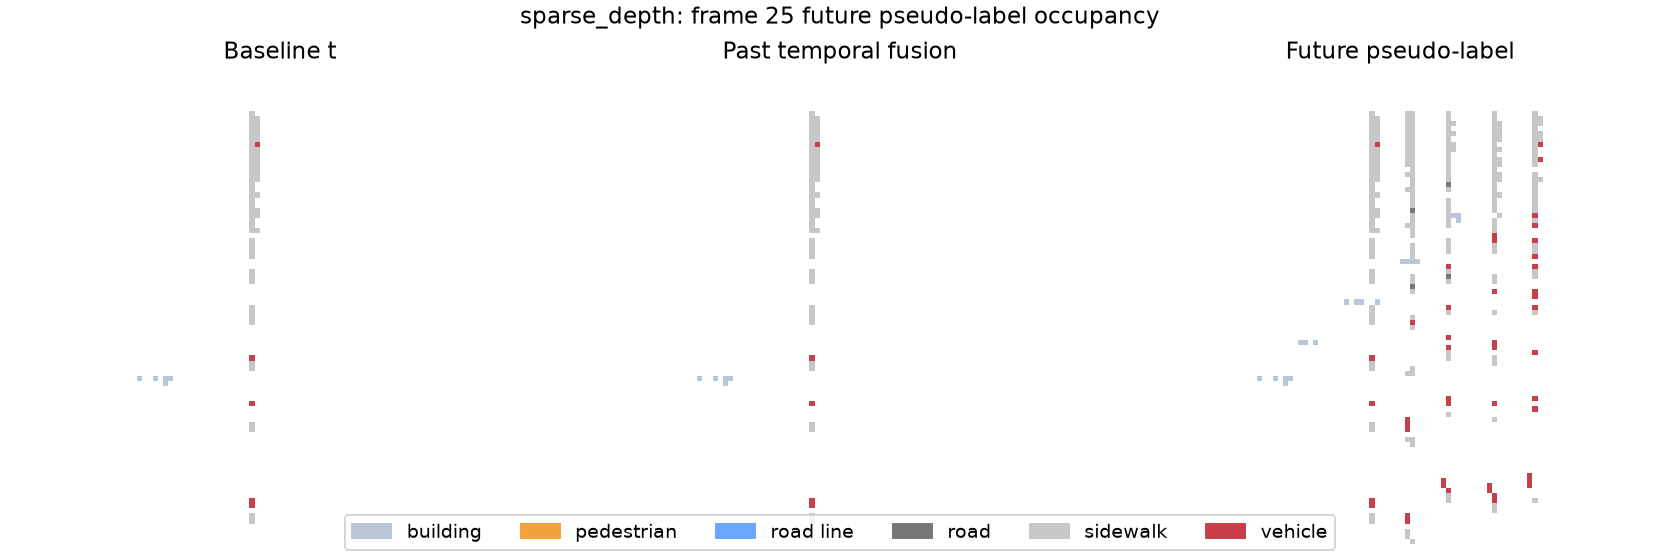

**dense_traffic / dense_traffic_00004_20.png**

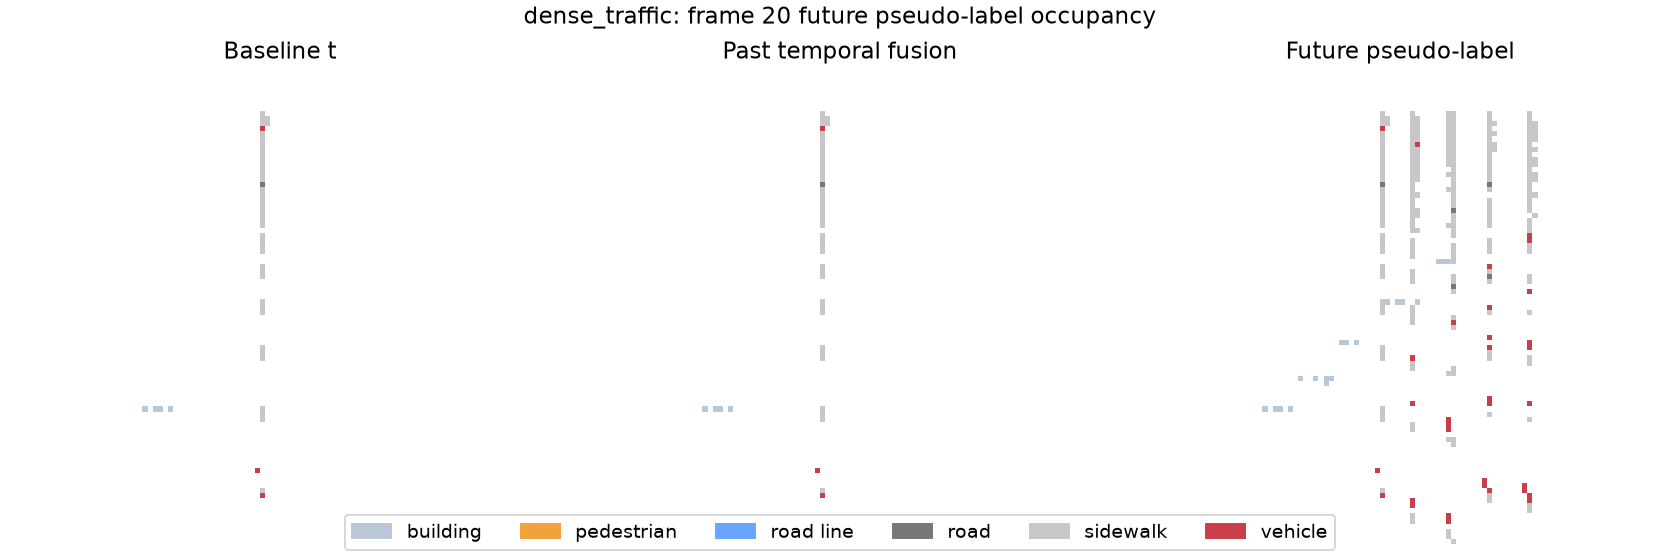

**dense_traffic / dense_traffic_00005_25.png**

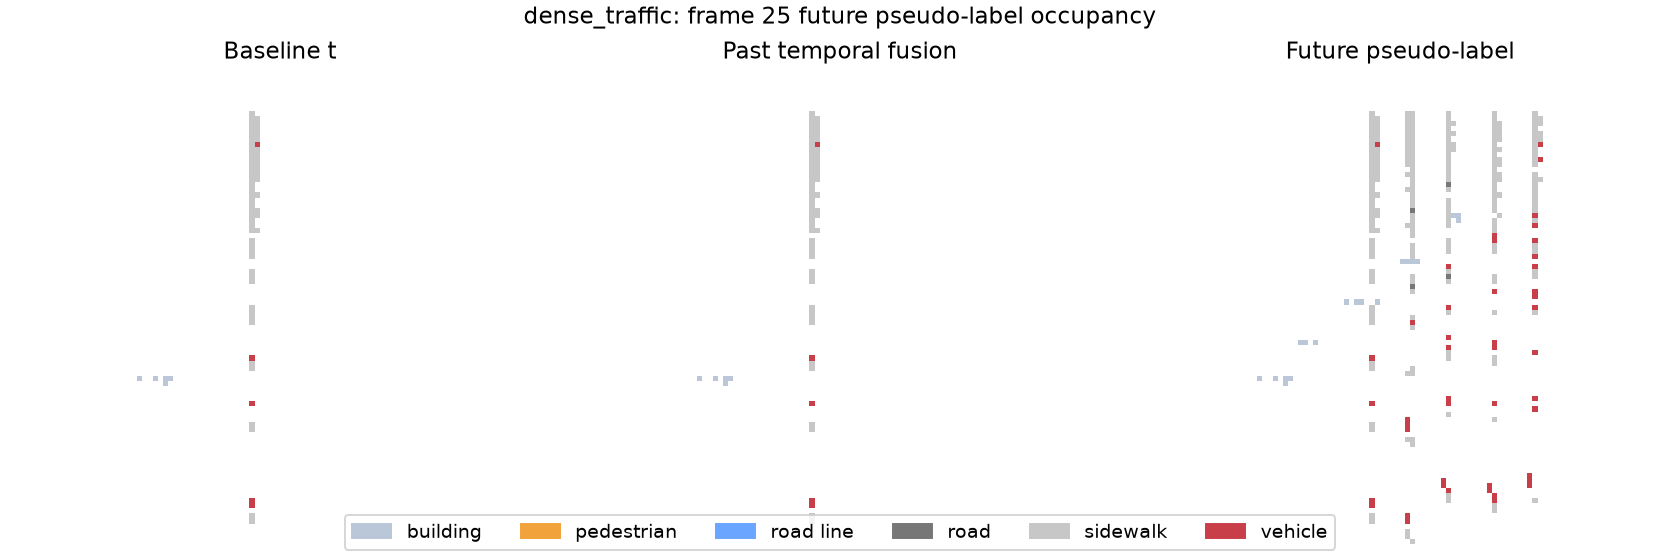

**high_disagreement / high_disagreement_00095_475.png**

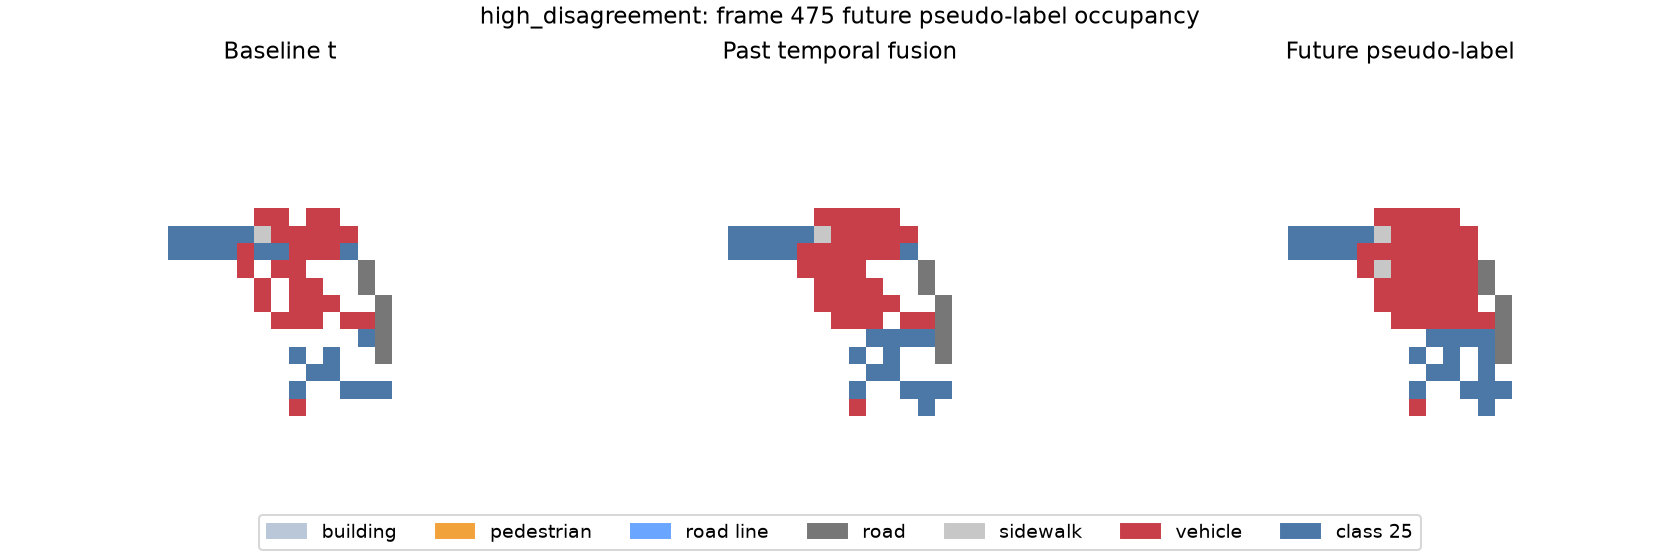

**high_disagreement / high_disagreement_00097_485.png**

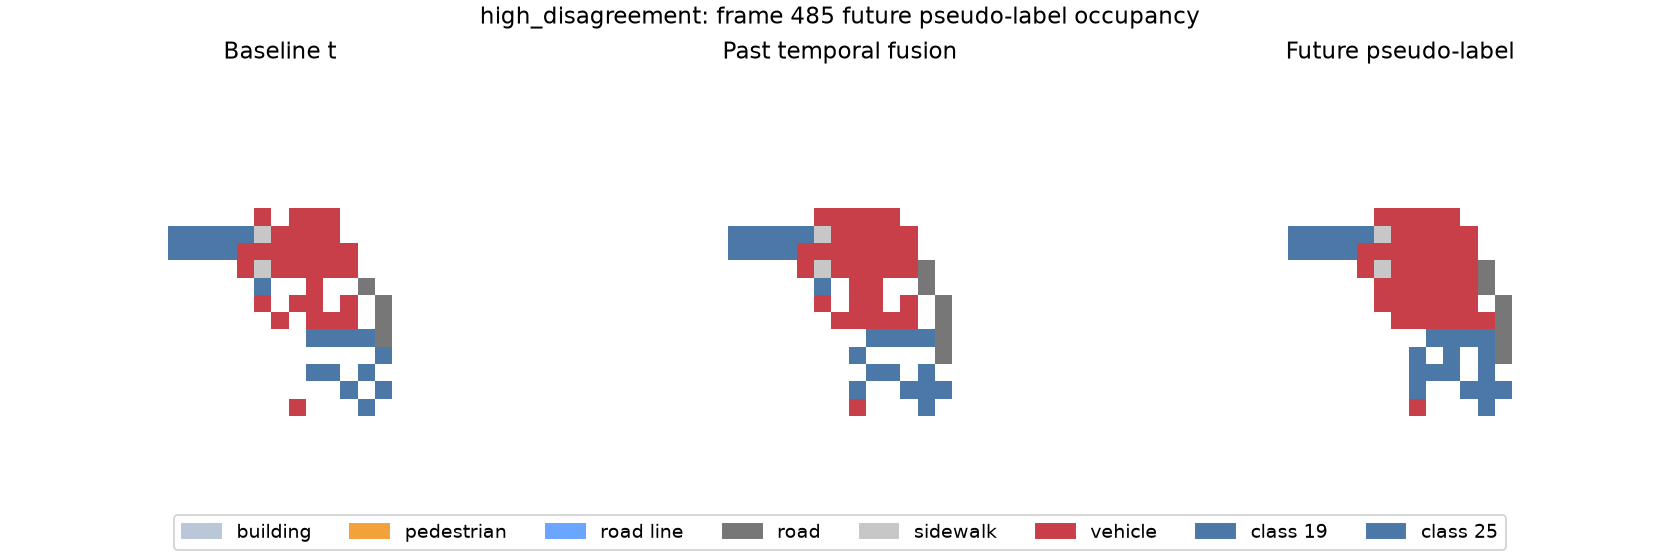

In [6]:
for image_path in artifacts.bev_images:
    display(Markdown(f"**{Path(image_path).parent.name} / {Path(image_path).name}**"))
    display(Image(filename=str(image_path)))


## 7. Interpretation Notes


In [7]:
notes = []
for slice_name, slice_df in df.groupby("slice"):
    vehicle_rows = slice_df[slice_df["class_name"] == "vehicle"]
    if vehicle_rows.empty:
        continue
    vehicle = vehicle_rows.iloc[0]
    if not bool(vehicle["informative"]):
        notes.append(f"{slice_name}: vehicle IoU is non-informative because union is empty.")
    elif vehicle["delta"] > 0:
        notes.append(f"{slice_name}: temporal fusion improves vehicle future-pseudo IoU by {vehicle['delta']:+.3f}.")
    elif vehicle["delta"] == 0:
        notes.append(f"{slice_name}: temporal fusion preserves vehicle future-pseudo IoU.")
    else:
        notes.append(f"{slice_name}: temporal fusion reduces vehicle future-pseudo IoU by {vehicle['delta']:+.3f}.")

notes.append("Inspect BEV examples before making any qualitative claim; this notebook is diagnostic, not a final benchmark.")
display(Markdown("\n".join(f"- {note}" for note in notes)))


- dense_traffic: temporal fusion preserves vehicle future-pseudo IoU.
- high_disagreement: temporal fusion improves vehicle future-pseudo IoU by +0.079.
- sparse_depth: temporal fusion improves vehicle future-pseudo IoU by +0.010.
- vehicle_change: temporal fusion improves vehicle future-pseudo IoU by +0.001.
- Inspect BEV examples before making any qualitative claim; this notebook is diagnostic, not a final benchmark.